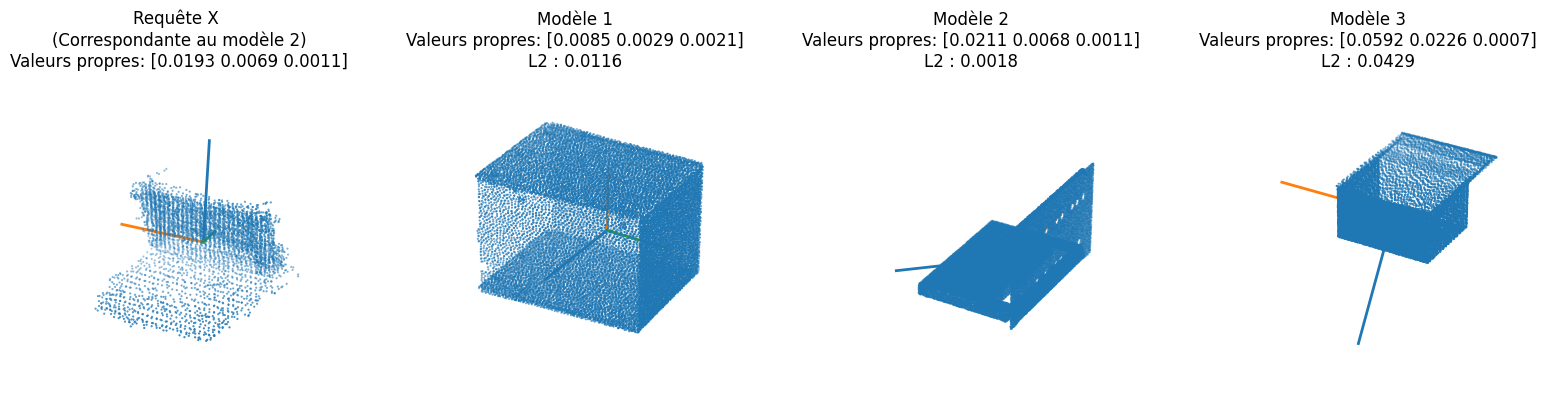

In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# Charger les fichiers
pcd1 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/Scan/segment_2.ply")
cad1 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/779632.ply")
cad2 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/785582.ply")
cad3 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/793998.ply")

# Mise à l'échelle des CADs
for cad in [cad1, cad2, cad3]:
    cad.points = o3d.utility.Vector3dVector(np.asarray(cad.points) / 1000)

data = [pcd1, cad1, cad2, cad3]
titles = ["Requête X \n(Correspondante au modèle 2)", "Modèle 1", "Modèle 2", "Modèle 3"]

# Fonction pour extraire les valeurs et vecteurs propres
def compute_eigen(pcd):
    pts = np.asarray(pcd.points)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

# Calcul des valeurs propres du scan
eigvals_scan, _ = compute_eigen(pcd1)

# Affichage
fig = plt.figure(figsize=(16, 4))
for i, pcd in enumerate(data):
    ax = fig.add_subplot(1, 4, i + 1, projection='3d')
    pts = np.asarray(pcd.points)
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)

    eigvals, eigvecs = compute_eigen(pcd)
    center = np.mean(pts, axis=0)

    # Tracer les vecteurs propres
    for j in range(3):
        vec = eigvecs[:, j] * eigvals[j] * 25
        ax.plot(
            [center[0], center[0] + vec[0]],
            [center[1], center[1] + vec[1]],
            [center[2], center[2] + vec[2]],
            linewidth=2
        )

    # Calcul de la distance L2 entre scan et CADs
    if i > 0:
        l2_dist = np.linalg.norm(eigvals_scan - eigvals)
        title = f"{titles[i]}\nVP : {eigvals.round(4)}\nL2 : {l2_dist:.4f}"
    else:
        title = f"{titles[i]}\nVP: {eigvals.round(4)}"

    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


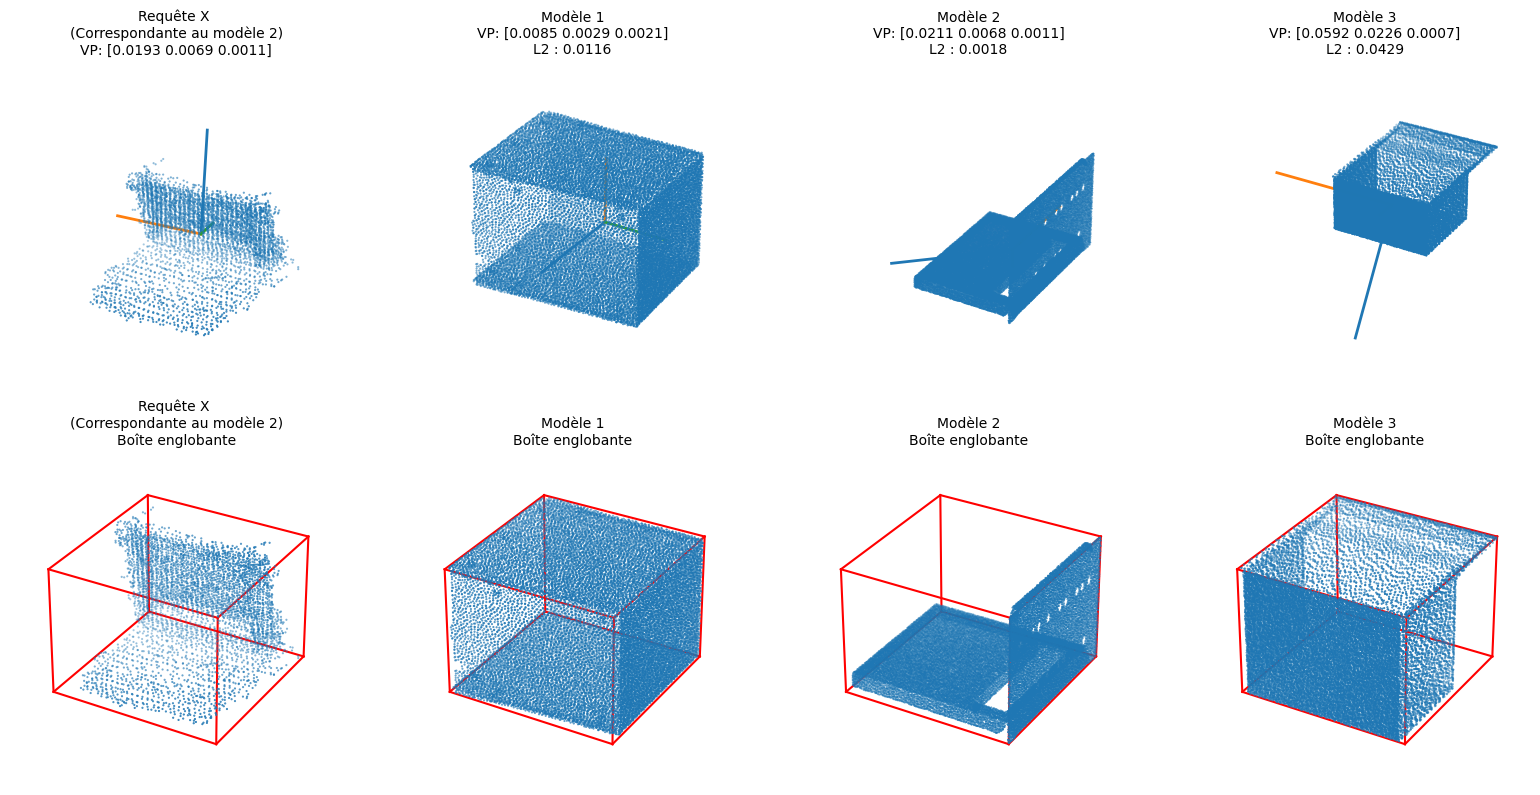

In [1]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# Charger les fichiers
pcd1 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/Scan/segment_2.ply")
cad1 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/779632.ply")
cad2 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/785582.ply")
cad3 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/793998.ply")

# Mise à l'échelle des CADs
for cad in [cad1, cad2, cad3]:
    cad.points = o3d.utility.Vector3dVector(np.asarray(cad.points) / 1000)

data = [pcd1, cad1, cad2, cad3]
titles = ["Requête X \n(Correspondante au modèle 2)", "Modèle 1", "Modèle 2", "Modèle 3"]

def compute_eigen(pcd):
    pts = np.asarray(pcd.points)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

eigvals_scan, _ = compute_eigen(pcd1)

fig = plt.figure(figsize=(16, 8))

for i, pcd in enumerate(data):
    pts = np.asarray(pcd.points)

    # Première ligne : vecteurs propres
    ax1 = fig.add_subplot(2, 4, i + 1, projection='3d')
    ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    eigvals, eigvecs = compute_eigen(pcd)
    center = np.mean(pts, axis=0)

    for j in range(3):
        vec = eigvecs[:, j] * eigvals[j] * 25
        ax1.plot([center[0], center[0] + vec[0]],
                 [center[1], center[1] + vec[1]],
                 [center[2], center[2] + vec[2]], linewidth=2)

    if i > 0:
        l2_dist = np.linalg.norm(eigvals_scan - eigvals)
        title = f"{titles[i]}\nVP: {eigvals.round(4)}\nL2 : {l2_dist:.4f}"
    else:
        title = f"{titles[i]}\nVP: {eigvals.round(4)}"

    ax1.set_title(title, fontsize=10)
    ax1.set_axis_off()

    # Deuxième ligne : boîte englobante
    ax2 = fig.add_subplot(2, 4, i + 5, projection='3d')
    ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)

    min_bound = pts.min(axis=0)
    max_bound = pts.max(axis=0)
    corners = np.array([[x, y, z] for x in [min_bound[0], max_bound[0]]
                                  for y in [min_bound[1], max_bound[1]]
                                  for z in [min_bound[2], max_bound[2]]])

    box_edges = [
        (0, 1), (0, 2), (0, 4), (1, 3), (1, 5),
        (2, 3), (2, 6), (3, 7), (4, 5), (4, 6),
        (5, 7), (6, 7)
    ]
    for edge in box_edges:
        p1, p2 = corners[edge[0]], corners[edge[1]]
        ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='r')

    ax2.set_title(f"{titles[i]}\nBoîte englobante", fontsize=10)
    ax2.set_axis_off()

plt.tight_layout()
plt.show()

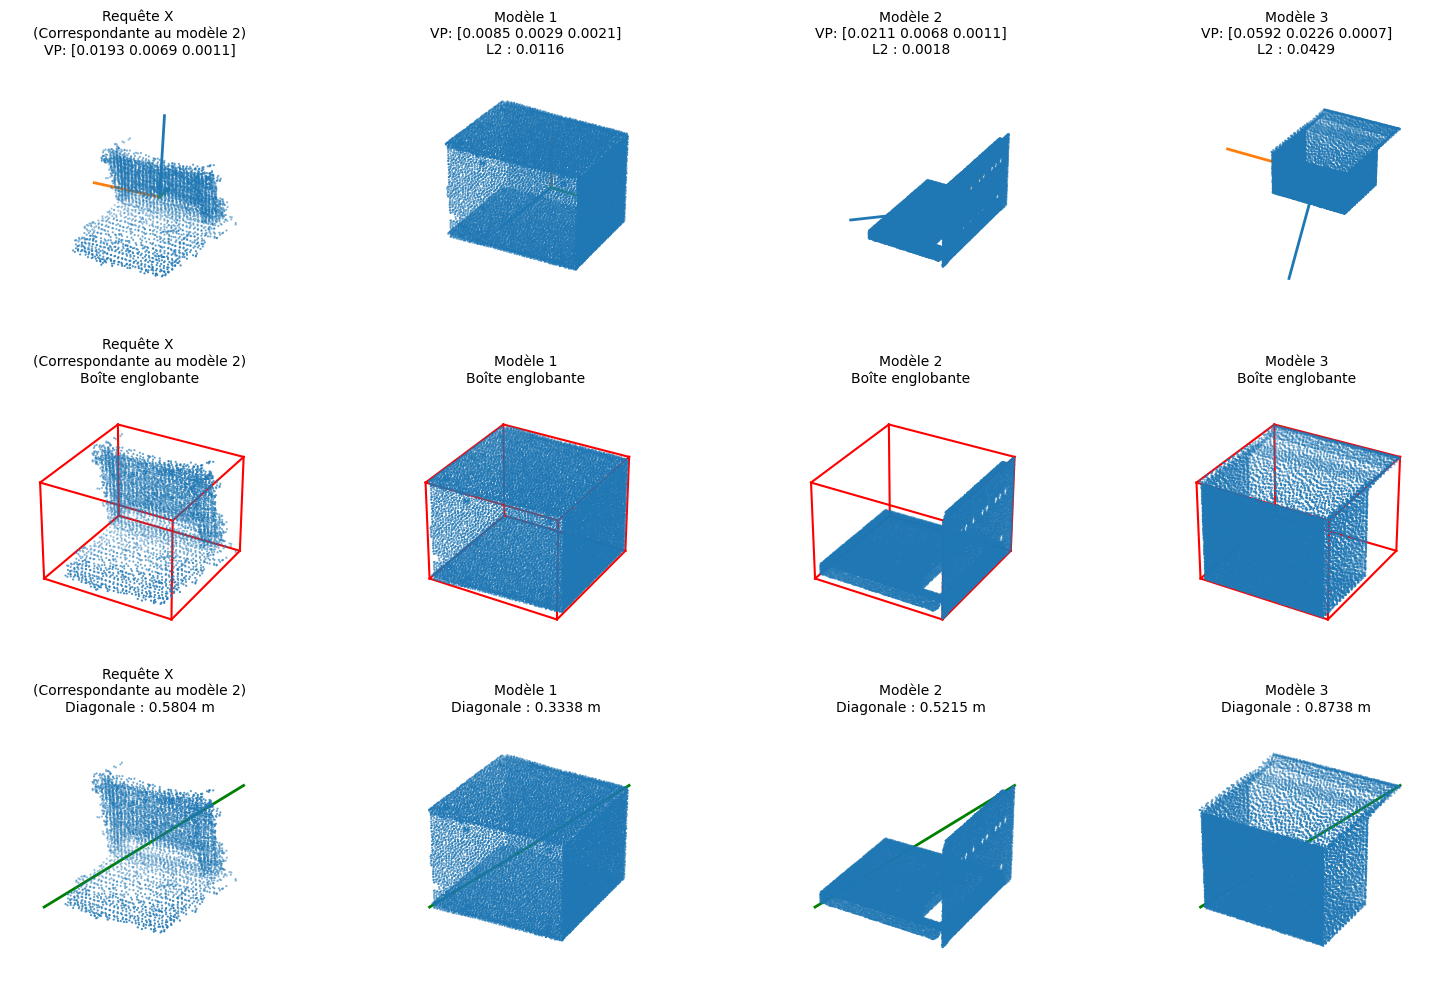

In [2]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# Charger les fichiers
pcd1 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/Scan/segment_2.ply")
cad1 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/779632.ply")
cad2 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/785582.ply")
cad3 = o3d.io.read_point_cloud("/root/gedi/bindmount/data/samples/sample_piece/CAD/793998.ply")

# Mise à l'échelle des CADs
for cad in [cad1, cad2, cad3]:
    cad.points = o3d.utility.Vector3dVector(np.asarray(cad.points) / 1000)

data = [pcd1, cad1, cad2, cad3]
titles = ["Requête X \n(Correspondante au modèle 2)", "Modèle 1", "Modèle 2", "Modèle 3"]

# Fonction pour extraire les valeurs et vecteurs propres
def compute_eigen(pcd):
    pts = np.asarray(pcd.points)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

eigvals_scan, _ = compute_eigen(pcd1)

fig = plt.figure(figsize=(16, 10))

for i, pcd in enumerate(data):
    pts = np.asarray(pcd.points)

    # Ligne 1 : vecteurs propres
    ax1 = fig.add_subplot(3, 4, i + 1, projection='3d')
    ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    eigvals, eigvecs = compute_eigen(pcd)
    center = np.mean(pts, axis=0)

    for j in range(3):
        vec = eigvecs[:, j] * eigvals[j] * 25
        ax1.plot([center[0], center[0] + vec[0]],
                 [center[1], center[1] + vec[1]],
                 [center[2], center[2] + vec[2]], linewidth=2)

    if i > 0:
        l2_dist = np.linalg.norm(eigvals_scan - eigvals)
        title = f"{titles[i]}\nVP: {eigvals.round(4)}\nL2 : {l2_dist:.4f}"
    else:
        title = f"{titles[i]}\nVP: {eigvals.round(4)}"

    ax1.set_title(title, fontsize=10)
    ax1.set_axis_off()

    # Ligne 2 : boîte englobante
    ax2 = fig.add_subplot(3, 4, i + 5, projection='3d')
    ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    min_bound = pts.min(axis=0)
    max_bound = pts.max(axis=0)
    corners = np.array([[x, y, z] for x in [min_bound[0], max_bound[0]]
                                  for y in [min_bound[1], max_bound[1]]
                                  for z in [min_bound[2], max_bound[2]]])
    box_edges = [
        (0, 1), (0, 2), (0, 4), (1, 3), (1, 5),
        (2, 3), (2, 6), (3, 7), (4, 5), (4, 6),
        (5, 7), (6, 7)
    ]
    for edge in box_edges:
        p1, p2 = corners[edge[0]], corners[edge[1]]
        ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='r')
    ax2.set_title(f"{titles[i]}\nBoîte englobante", fontsize=10)
    ax2.set_axis_off()

    # Ligne 3 : diagonale
    ax3 = fig.add_subplot(3, 4, i + 9, projection='3d')
    ax3.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    # Tracer la diagonale
    ax3.plot(
        [min_bound[0], max_bound[0]],
        [min_bound[1], max_bound[1]],
        [min_bound[2], max_bound[2]],
        color='g', linewidth=2, label='Diagonale'
    )
    diag_length = np.linalg.norm(max_bound - min_bound)
    ax3.set_title(f"{titles[i]}\nDiagonale : {diag_length:.4f} m", fontsize=10)
    ax3.set_axis_off()

plt.tight_layout()
plt.show()

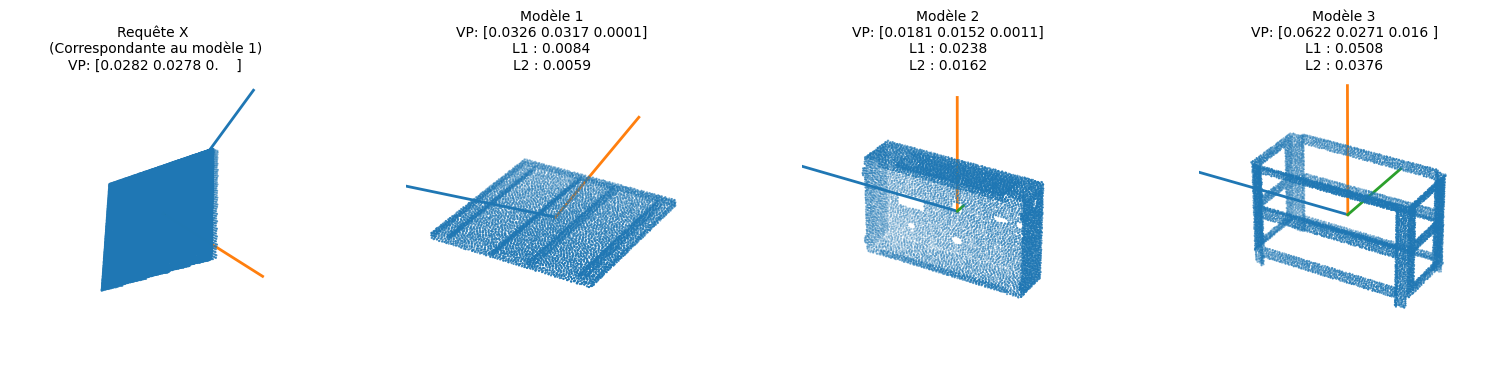

In [20]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

def set_axes_equal(ax, pts):
    """Ajuste les axes X/Y/Z à la même échelle pour un affichage 3D sans distorsion."""
    limits = np.array([pts[:, 0].min(), pts[:, 0].max(),
                       pts[:, 1].min(), pts[:, 1].max(),
                       pts[:, 2].min(), pts[:, 2].max()]).reshape(3, 2)
    centers = limits.mean(axis=1)
    max_range = (limits[:, 1] - limits[:, 0]).max() / 2

    for axis, center in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], centers):
        axis(center - max_range, center + max_range)

# Charger les fichiers
pcd1 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x100/scans/preprocess_point_cloud/776560.ply")
cad1 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x100/cads/preprocess/776560.ply")
cad2 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x100/cads/preprocess/779530.ply")
cad3 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x100/cads/preprocess/781070.ply")

data = [pcd1, cad1, cad2, cad3]
titles = ["Requête X \n(Correspondante au modèle 1)", "Modèle 1", "Modèle 2", "Modèle 3"]

def compute_eigen(pcd):
    pts = np.asarray(pcd.points)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

eigvals_scan, _ = compute_eigen(pcd1)

# Référence pour volumes et diagonales
ref_pts = np.asarray(pcd1.points)
ref_min, ref_max = ref_pts.min(axis=0), ref_pts.max(axis=0)
ref_vol = np.prod(ref_max - ref_min)
ref_diag = np.linalg.norm(ref_max - ref_min)

fig = plt.figure(figsize=(16, 10))

for i, pcd in enumerate(data):
    pts = np.asarray(pcd.points)

    # Ligne 1 : vecteurs propres
    ax1 = fig.add_subplot(3, 4, i + 1, projection='3d')
    ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    eigvals, eigvecs = compute_eigen(pcd)
    center = np.mean(pts, axis=0)
    for j in range(3):
        vec = eigvecs[:, j] * eigvals[j] * 25
        ax1.plot([center[0], center[0] + vec[0]],
                 [center[1], center[1] + vec[1]],
                 [center[2], center[2] + vec[2]], linewidth=2)

    if i > 0:
        l1_dist = np.linalg.norm(eigvals_scan - eigvals, ord=1)
        l2_dist = np.linalg.norm((eigvals_scan - eigvals), ord=2)
        title = f"{titles[i]}\nVP: {eigvals.round(4)}\nL1 : {l1_dist:.4f}\nL2 : {l2_dist:.4f}"
    else:
        title = f"{titles[i]}\nVP: {eigvals.round(4)}"

    ax1.set_title(title, fontsize=10)
    ax1.set_axis_off()
    set_axes_equal(ax1, pts)

    # # Ligne 2 : boîte englobante + volume
    # ax2 = fig.add_subplot(3, 4, i + 5, projection='3d')
    # ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    # min_bound = pts.min(axis=0)
    # max_bound = pts.max(axis=0)
    # box_size = max_bound - min_bound
    # vol = np.prod(box_size)
    # vol_diff = vol - ref_vol if i > 0 else 0

    # corners = np.array([[x, y, z] for x in [min_bound[0], max_bound[0]]
    #                               for y in [min_bound[1], max_bound[1]]
    #                               for z in [min_bound[2], max_bound[2]]])
    # box_edges = [
    #     (0, 1), (0, 2), (0, 4), (1, 3), (1, 5),
    #     (2, 3), (2, 6), (3, 7), (4, 5), (4, 6),
    #     (5, 7), (6, 7)
    # ]
    # for edge in box_edges:
    #     p1, p2 = corners[edge[0]], corners[edge[1]]
    #     ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='r')

    # if i > 0:
    #     ax2.set_title(f"{titles[i]}\nVolume : {vol:.4e}\nΔVol : {vol_diff:.2e}", fontsize=10)
    # else:
    #     ax2.set_title(f"{titles[i]}\nVolume : {vol:.4e}", fontsize=10)
    # ax2.set_axis_off()
    # set_axes_equal(ax2, pts)

    # # Ligne 3 : diagonale
    # ax3 = fig.add_subplot(3, 4, i + 9, projection='3d')
    # ax3.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    # diag = np.linalg.norm(max_bound - min_bound)
    # diag_diff = diag - ref_diag if i > 0 else 0

    # ax3.plot(
    #     [min_bound[0], max_bound[0]],
    #     [min_bound[1], max_bound[1]],
    #     [min_bound[2], max_bound[2]],
    #     color='g', linewidth=2
    # )
    # if i > 0:
    #     ax3.set_title(f"{titles[i]}\nDiag: {diag:.4f} m\nΔDiag: {diag_diff:.4f}", fontsize=10)
    # else:
    #     ax3.set_title(f"{titles[i]}\nDiag: {diag:.4f} m", fontsize=10)

    # ax3.set_axis_off()
    # set_axes_equal(ax3, pts)

plt.tight_layout()
plt.show()

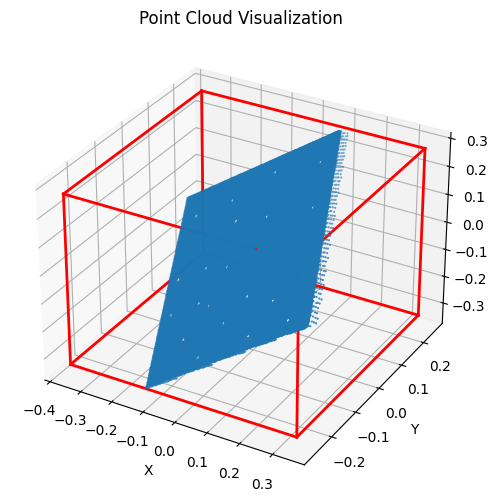

In [16]:
pcd1 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x100/scans/preprocess_point_cloud/776560.ply")

# plot 3d
plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
pts = np.asarray(pcd1.points)
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
ax.set_title("Point Cloud Visualization")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

xmax = np.max(pts[:, 0])
xmin = np.min(pts[:, 0])
ymax = np.max(pts[:, 1])
ymin = np.min(pts[:, 1])
zmax = np.max(pts[:, 2])
zmin = np.min(pts[:, 2])

# Define the 8 corners of the bounding box
corners = np.array([
    [xmin, ymin, zmin],
    [xmax, ymin, zmin],
    [xmax, ymax, zmin],
    [xmin, ymax, zmin],
    [xmin, ymin, zmax],
    [xmax, ymin, zmax],
    [xmax, ymax, zmax],
    [xmin, ymax, zmax]
])

# Define the 12 edges (pairs of corner indices)
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),  # bottom face
    (4, 5), (5, 6), (6, 7), (7, 4),  # top face
    (0, 4), (1, 5), (2, 6), (3, 7)   # vertical edges
]

# Draw all edges
for start, end in edges:
    ax.plot(
        [corners[start, 0], corners[end, 0]],
        [corners[start, 1], corners[end, 1]],
        [corners[start, 2], corners[end, 2]],
        color='r', linewidth=2
    )


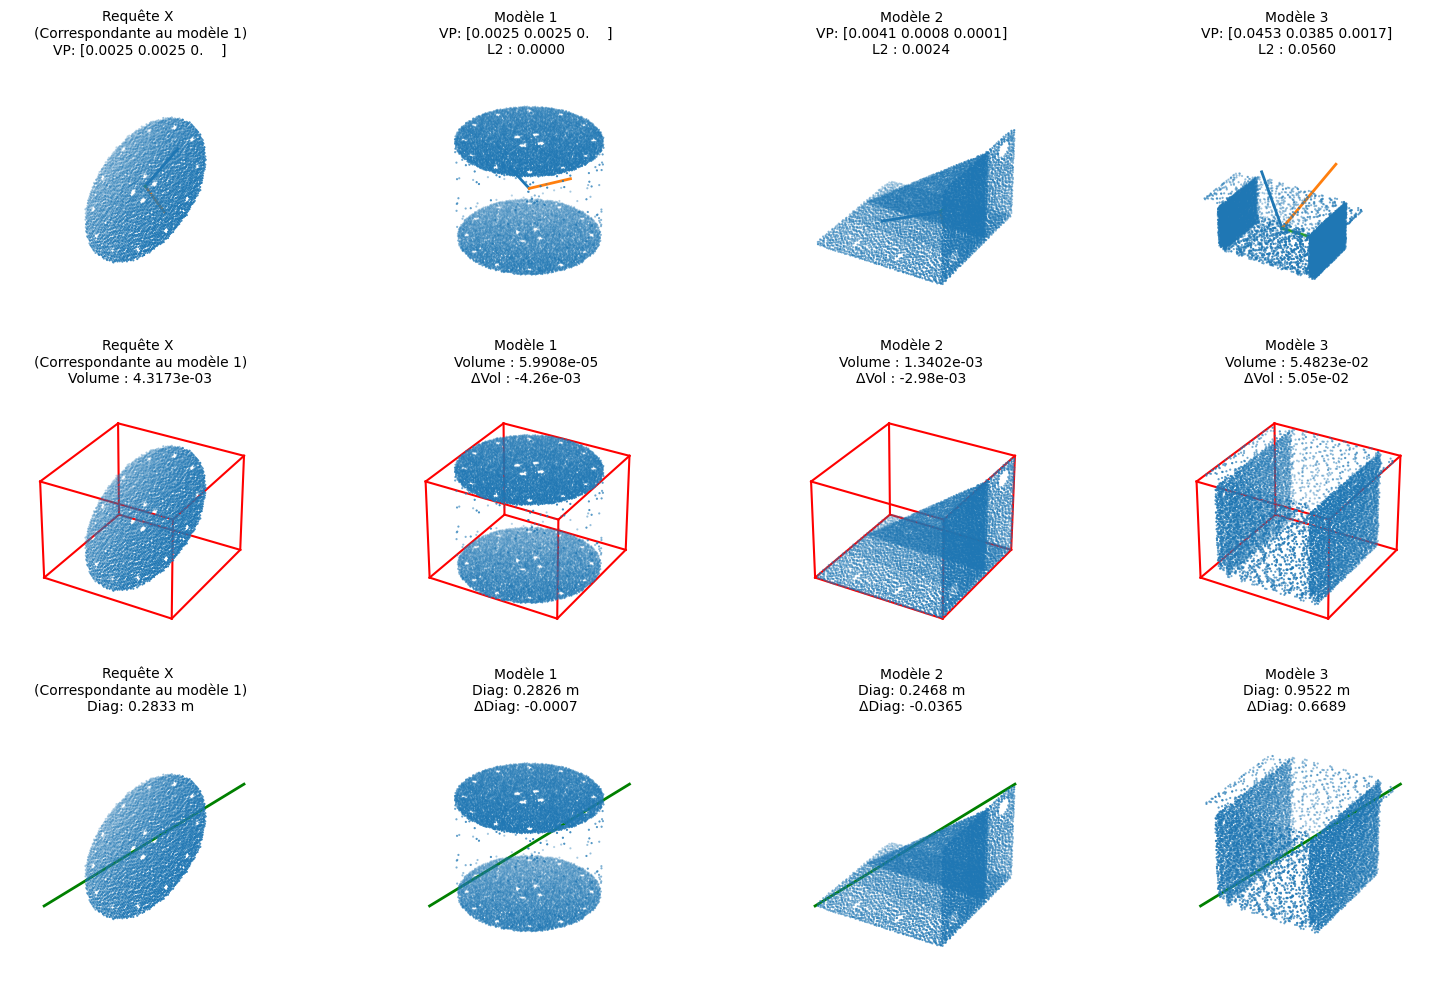

In [8]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# Charger les fichiers
pcd1 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x100/scans/preprocess_point_cloud/777133.ply")
cad1 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x100/cads/preprocess/777133.ply")
cad2 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x50/cads/preprocess/781282.ply")
cad3 = o3d.io.read_point_cloud("/root/gedi/bindmount/test_set_30x50/cads/preprocess/785149.ply")

data = [pcd1, cad1, cad2, cad3]
titles = ["Requête X \n(Correspondante au modèle 1)", "Modèle 1", "Modèle 2", "Modèle 3"]

def compute_eigen(pcd):
    pts = np.asarray(pcd.points)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

eigvals_scan, _ = compute_eigen(pcd1)

# Référence pour volumes et diagonales
ref_pts = np.asarray(pcd1.points)
ref_min, ref_max = ref_pts.min(axis=0), ref_pts.max(axis=0)
ref_vol = np.prod(ref_max - ref_min)
ref_diag = np.linalg.norm(ref_max - ref_min)

fig = plt.figure(figsize=(16, 10))

for i, pcd in enumerate(data):
    pts = np.asarray(pcd.points)

    # Ligne 1 : vecteurs propres
    ax1 = fig.add_subplot(3, 4, i + 1, projection='3d')
    ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    eigvals, eigvecs = compute_eigen(pcd)
    center = np.mean(pts, axis=0)

    for j in range(3):
        vec = eigvecs[:, j] * eigvals[j] * 25
        ax1.plot([center[0], center[0] + vec[0]],
                 [center[1], center[1] + vec[1]],
                 [center[2], center[2] + vec[2]], linewidth=2)

    if i > 0:
        l2_dist = np.linalg.norm(eigvals_scan - eigvals)
        title = f"{titles[i]}\nVP: {eigvals.round(4)}\nL2 : {l2_dist:.4f}"
    else:
        title = f"{titles[i]}\nVP: {eigvals.round(4)}"

    ax1.set_title(title, fontsize=10)
    ax1.set_axis_off()

    # Ligne 2 : boîte englobante + volume
    ax2 = fig.add_subplot(3, 4, i + 5, projection='3d')
    ax2.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    min_bound = pts.min(axis=0)
    max_bound = pts.max(axis=0)
    box_size = max_bound - min_bound
    vol = np.prod(box_size)
    vol_diff = vol - ref_vol if i > 0 else 0

    corners = np.array([[x, y, z] for x in [min_bound[0], max_bound[0]]
                                  for y in [min_bound[1], max_bound[1]]
                                  for z in [min_bound[2], max_bound[2]]])
    box_edges = [
        (0, 1), (0, 2), (0, 4), (1, 3), (1, 5),
        (2, 3), (2, 6), (3, 7), (4, 5), (4, 6),
        (5, 7), (6, 7)
    ]
    for edge in box_edges:
        p1, p2 = corners[edge[0]], corners[edge[1]]
        ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='r')

    if i > 0:
        ax2.set_title(f"{titles[i]}\nVolume : {vol:.4e}\nΔVol : {vol_diff:.2e}", fontsize=10)
    else:
        ax2.set_title(f"{titles[i]}\nVolume : {vol:.4e}", fontsize=10)
    ax2.set_axis_off()

    # Ligne 3 : diagonale entre min et max
    ax3 = fig.add_subplot(3, 4, i + 9, projection='3d')
    ax3.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.3)
    diag = np.linalg.norm(max_bound - min_bound)
    diag_diff = diag - ref_diag if i > 0 else 0

    ax3.plot(
        [min_bound[0], max_bound[0]],
        [min_bound[1], max_bound[1]],
        [min_bound[2], max_bound[2]],
        color='g', linewidth=2, label='Diagonale'
    )
    if i > 0:
        ax3.set_title(f"{titles[i]}\nDiag: {diag:.4f} m\nΔDiag: {diag_diff:.4f}", fontsize=10)
    else:
        ax3.set_title(f"{titles[i]}\nDiag: {diag:.4f} m", fontsize=10)

    ax3.set_axis_off()

plt.tight_layout()
plt.show()